# Curated reported reference and frontier-orbital gap comparison

This companion notebook documents the complete curated reference and compares its frontier-orbital gaps with the candidates remaining after self-reaction exclusion (SI 6.3).

All reported-reaction records come from `Data/Reported_BO/Reported Bioorthogonal Reactions for Selection.csv`, through the same loader as notebook `03`. The full table is used without additional energy or structural exclusions.

The four distortion/interaction distribution panels and the subsequent 4pi distortion-fraction plot are maintained together in notebook `03` (SI 6.4), followed by the actual fraction selection (SI 6.5). This notebook does not duplicate that analysis or write candidate-selection tables.

In [18]:
from pathlib import Path
import os
import sys

start = Path.cwd().resolve()
REPO_ROOT = next((p for p in (start, *start.parents)
                  if (p / "Code/model_train.py").is_file()), None)
if REPO_ROOT is None:
    raise FileNotFoundError("Start Jupyter inside the CycloAddGenerator repository.")
for folder in (REPO_ROOT / "notebooks", REPO_ROOT / "notebooks/04_discovery"):
    if str(folder) not in sys.path:
        sys.path.insert(0, str(folder))
os.chdir(REPO_ROOT)

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from IPython.display import display
from _workflow_paths import SCREEN_DIR, FMO_CSV, require_file
from _discovery_comparison import (
    REFERENCE_RELATIVE_PATH, POPULATION_STYLES, load_reference,
    orbital_gaps, energy_values, describe_populations, plot_frequency_curves,
)

plt.rcParams.update({"font.family": "sans-serif", "font.sans-serif": ["Arial", "DejaVu Sans"]})

## 1. Load the complete curated reference

Reference energies are DFT results. Display its size and energy summaries to document the population used consistently in both notebooks. Candidate orbital energies use the same saved FMO table as notebook `03`; reference orbital energies use the reference FMO table. Both tables store energies in eV.

In [20]:
reference = load_reference(REPO_ROOT)
candidates = pd.read_csv(require_file(SCREEN_DIR / "3_DropDimer.csv"))
output_dir = REPO_ROOT / "Data/Analysis_DI_Selection_Reported_BO"
output_dir.mkdir(parents=True, exist_ok=True)
REFERENCE_FMO = Path(os.environ.get("CYCLOADD_REFERENCE_FMO_CSV", str(output_dir / "FMO_Energy.csv")))
candidate_fmo = pd.read_csv(require_file(FMO_CSV)).set_index("Index")
reference_fmo = pd.read_csv(require_file(REFERENCE_FMO)).set_index("Index")
candidate_gaps = orbital_gaps(candidates, candidate_fmo)
reference_gaps = orbital_gaps(reference, reference_fmo)
print(f"Reference source: {REFERENCE_RELATIVE_PATH.as_posix()}")
print({"candidate_pairs": len(candidates), "reference_reactions": len(reference)})
display(energy_values(reference).describe().T)

Reference source: Data/Reported_BO/Reported Bioorthogonal Reactions for Selection.csv
{'candidate_pairs': 2932, 'reference_reactions': 158}


,count,mean,std,min,25%,50%,75%,max
4pi distortion,158.0,17.603060,2.986126,8.761082,16.180879,18.631362,19.741909,24.060900
2pi distortion,158.0,6.443675,2.394192,0.887092,4.680066,6.151684,8.763716,12.225705
Interaction,158.0,24.285667,3.818001,13.610242,22.496035,24.056891,26.278758,47.338487
Total distortion,158.0,24.046734,4.817983,12.663581,20.968678,25.222207,27.740888,35.754623
4pi distortion fraction,158.0,0.738956,0.061431,0.640217,0.680447,0.753844,0.780446,0.955366


## 2. Compare normal and inverse electron-demand gaps — SI 6.3

The horizontal axis is `LUMO(4pi) - HOMO(2pi)` and the vertical axis is `LUMO(2pi) - HOMO(4pi)`. Candidate pairs above the identity line have the smaller inverse-electron-demand gap. Marginal curves use shared bins spanning both populations and separately normalized histogram frequencies, with cubic splines as visual guides.

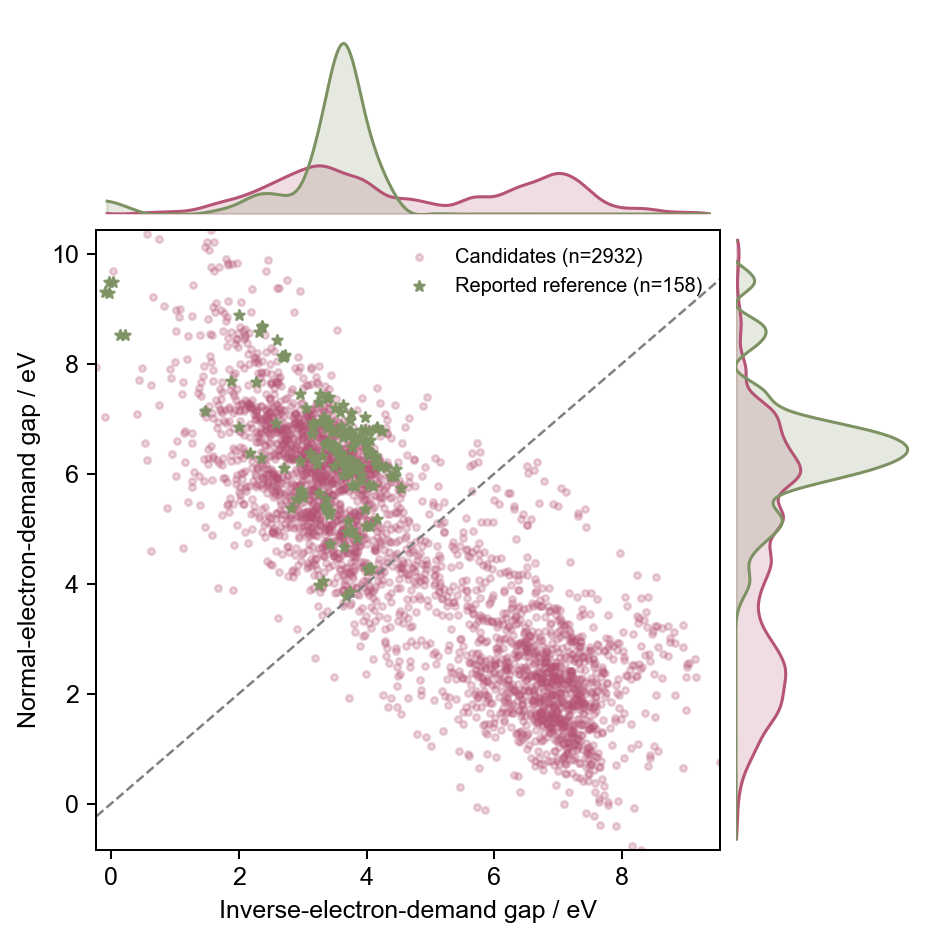

In [21]:
fig = plt.figure(figsize=(6, 6), dpi=180, facecolor="white")
grid = fig.add_gridspec(4, 4, hspace=0.08, wspace=0.08)
ax_main = fig.add_subplot(grid[1:, :3])
ax_top = fig.add_subplot(grid[0, :3], sharex=ax_main)
ax_right = fig.add_subplot(grid[1:, 3], sharey=ax_main)
gap_populations = [
    ("Candidates", candidate_gaps, POPULATION_STYLES[0][1]),
    ("Reported reference", reference_gaps, POPULATION_STYLES[1][1]),
]
for name, frame, color in gap_populations:
    ax_main.scatter(frame["inverse_gap"], frame["normal_gap"],
                    color=color, s=7 if name == "Candidates" else 18,
                    marker="o" if name == "Candidates" else "*",
                    alpha=0.25 if name == "Candidates" else 0.9,
                    label=f"{name} (n={len(frame)})")
x_bins = plot_frequency_curves(ax_top, [(name, frame["inverse_gap"], color)
                                      for name, frame, color in gap_populations])
y_bins = plot_frequency_curves(ax_right, [(name, frame["normal_gap"], color)
                                        for name, frame, color in gap_populations], vertical=True)
lower, upper = max(x_bins[0], y_bins[0]), min(x_bins[-1], y_bins[-1])
if lower < upper:
    ax_main.plot([lower, upper], [lower, upper], color="gray", linestyle="--", linewidth=1)
ax_main.set_xlim(x_bins[0], x_bins[-1])
ax_main.set_ylim(y_bins[0], y_bins[-1])
ax_main.set_xlabel("Inverse-electron-demand gap / eV")
ax_main.set_ylabel("Normal-electron-demand gap / eV")
ax_main.legend(frameon=False, fontsize=8)
ax_top.axis("off")
ax_right.axis("off")
for extension in ("png", "svg"):
    fig.savefig(output_dir / f"fmo_gap_distribution.{extension}", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

## 3. Classification summary and continuation

Summarize candidate FMO-gap ordering after visualizing the populations. Continue with notebook `03` for the four energy comparisons and the immediately following 4pi distortion-fraction distribution (SI 6.4), then the explicit fraction-selection step (SI 6.5).

In [22]:
inverse = candidate_gaps["inverse_gap"]
normal = candidate_gaps["normal_gap"]
display(pd.DataFrame([
    {"classification": "IEDDA: inverse gap < normal gap", "n": int((inverse < normal).sum())},
    {"classification": "Opposite gap ordering", "n": int((inverse > normal).sum())},
    {"classification": "Equal gaps", "n": int((inverse == normal).sum())},
]))

,classification,n
0,IEDDA: inverse gap < normal gap,1589
1,Opposite gap ordering,1343
2,Equal gaps,0
